In [51]:
import torch
print('PyTorch version:', torch.__version__)
from torch import nn
from torch import optim
from torch.utils.data import DataLoader

import torchvision
print('Torchvision version:', torchvision.__version__)
from torchvision import datasets
from torchvision import transforms
from torchvision.utils import make_grid

from tqdm import tqdm
# from torchinfo import summary

import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device is:', device, '\n')

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import os
from torchvision.io import decode_image
from PIL import Image

PyTorch version: 2.5.1+cu118
Torchvision version: 0.20.1+cu118
Device is: cpu 



Config Section

In [ ]:
initial_channel_count = 1 #number of channels the initial image has, possibly add an output channel count if we want a different output

UNet_params = {
    "scale_rate" : 2, #integer controlling the amount the spatial resolution of the feature map decreases/increases during the down/upsampling process
    "max_channels" : 128, #integer power of scale_rate, the maximum amount of channels the feature map reaches during downsampling
    "time_embedding_dimensions" : 256, #integer controlling dimensionality of positional embedding vector of the timesteps
    "num_conv_blocks_per_scaling_block" : 1 #integer that controls how many convolutional blocks there are per up/down sampling block
}


diffusion_parameters = {
    'scheduling_type' : 'linear',
    "num_timesteps" : 1000,
    "max_variance" : 0.02
}

batch_size = 1
num_epochs = 20
criterion = nn.L1Loss()

#use_attention
#use_sparsity_masking

# optimizer = optim.AdamW(model.parameters(), lr=0.0001)

In [ ]:
from diffusion_module import diffusion
from Unet_import import UNet

diffusion_module = diffusion(startVariance=0, maxVariance=.2, diffusionSteps=1000, device='cpu')
model = UNet(t_dim=128)
optimizer = optim.AdamW(model.parameters(), lr = 0.0001)
# criterion = nn.L1Loss()


Training Cycle

In [62]:
num_epochs = 1

for epoch in range(num_epochs):
    losses = []
    for data in training_dataloader:
        model.train()
        data = data.to(device)

        sparsity_mask = create_sparsity_mask(data)
        data = torch.cat([data, sparsity_mask], dim=1)
        
        t = torch.randint(low=0, high=1000, size=(data.shape[0],)).to(device)
        noise = torch.randn_like(data)
        x_t = ddpm.noisingProcess(input=data, noise=noise, timestep=t)

        prediction = model(x_t, t)
        predicted_sparsity_mask, predicted_feature_map = get_sparsity_mask(prediction)
        batch_loss = criterion(predicted_feature_map, data) #data, predicted_sparsity_mask, sparsity_mask)

        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()
        losses.append(batch_loss.item())
    training_per_epoch_loss = np.array(losses).mean()

    print(training_per_epoch_loss)

0.3968866765499115


c:\Users\roboc\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\loss.py:128: UserWarning: Using a target size (torch.Size([3, 2, 128, 128])) that is different to the input size (torch.Size([3, 1, 128, 128])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


In [63]:
def threshold(input, thresh = 5):
    return input[input<thresh]


sample_image = ddpm.ddpmReverse(model=model, num_samples=1, channels=2, img_size=128)
# threshold_image = threshold(sample_image)

sparsity_mask = create_sparsity_mask(sample_image)
sample_image = torch.cat([sample_image, ])

# print(type(sparsity_mask), type(featrue_map))
# print(sparsity_mask)

sparsified_map = induce_sparstiy(sample_image)
print(sparsified_map)

tensor([[[[nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          ...,
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan],
          [nan, nan, nan,  ..., nan, nan, nan]]]])


In [64]:
grid = make_grid(sparsified_map.detach().cpu(), nrow=16, normalize=True)

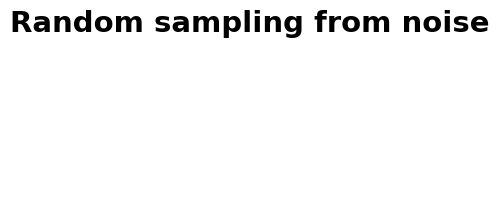

In [65]:
plt.figure(figsize=(12, 2))
plt.imshow(grid.permute(1, 2, 0), cmap='gray')
plt.axis(False)
plt.title('Random sampling from noise', fontsize=21, fontweight='bold');